# Regression model

## Import Library

In [45]:
# import library
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV


In [46]:
file_excel = "../dataset/dataset_featured.csv"


df = pd.read_csv(file_excel)

# lihat data
df.head()

,tanggal,Harga,Cabai_lag_1,Cabai_lag_7,RR_lag_45,RH_lag_30,RR_rolling_mean_14,Bulan
0,2024-06-15,71650.0,71650.0,65550.0,2.5,70.0,6.950000,6
1,2024-06-16,71650.0,71650.0,64450.0,5.0,76.0,6.414286,6
2,2024-06-17,71650.0,71650.0,63350.0,3.9,75.0,5.660714,6
3,2024-06-18,71650.0,71650.0,65000.0,2.8,66.0,3.160714,6
4,2024-06-19,77500.0,71650.0,65000.0,1.7,70.0,1.494048,6


In [47]:
df['tanggal'] = pd.to_datetime(df['tanggal'])
df.head()

,tanggal,Harga,Cabai_lag_1,Cabai_lag_7,RR_lag_45,RH_lag_30,RR_rolling_mean_14,Bulan
0,2024-06-15,71650.0,71650.0,65550.0,2.5,70.0,6.950000,6
1,2024-06-16,71650.0,71650.0,64450.0,5.0,76.0,6.414286,6
2,2024-06-17,71650.0,71650.0,63350.0,3.9,75.0,5.660714,6
3,2024-06-18,71650.0,71650.0,65000.0,2.8,66.0,3.160714,6
4,2024-06-19,77500.0,71650.0,65000.0,1.7,70.0,1.494048,6


## split data

In [48]:
# fitur
X = df.drop(columns=['Harga','tanggal'])
y = df['Harga']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (545, 6)
Test size: (137, 6)


## Buat Models

### Linear Regression

In [49]:
# define model
modelLR = LinearRegression()

# train model
modelLR.fit(X_train, y_train)

# prediksi
y_pred_LR = modelLR.predict(X_test)

# evaluasi
mae = mean_absolute_error(y_test, y_pred_LR)
mse = mean_squared_error(y_test, y_pred_LR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_LR)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 806.8642547382386
MSE: 1486971.8096715102
RMSE: 1219.4145356159693
R2: 0.9813815189682398


### Lasso Regression

In [50]:
# define model
modelLS = Lasso()

# train model
modelLS.fit(X_train, y_train)

# prediksi
y_pred_LS = modelLS.predict(X_test)

# evaluasi
mae = mean_absolute_error(y_test, y_pred_LS)
mse = mean_squared_error(y_test, y_pred_LS)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_LS)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 806.8182132641127
MSE: 1486783.852365973
RMSE: 1219.3374645134024
R2: 0.9813838723951879


### Ridge Regression

In [51]:
# define model
modelRR = Ridge()

# train model
modelRR.fit(X_train, y_train)

# prediksi
y_pred_RR = modelRR.predict(X_test)

# evaluasi
mae = mean_absolute_error(y_test, y_pred_RR)
mse = mean_squared_error(y_test, y_pred_RR)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_RR)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 806.8633008942166
MSE: 1486967.8823328074
RMSE: 1219.4129252770808
R2: 0.9813815681427304


### Random Forest

In [52]:
# Hyperparameter tuning untuk Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# define model
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# train model
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_
print(f"Best parameters: {rf_grid.best_params_}")

# prediksi
y_pred_RF = rf_grid.predict(X_test)

# evaluasi
mae = mean_absolute_error(y_test, y_pred_RF)
mse = mean_squared_error(y_test, y_pred_RF)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_RF)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
MAE: 877.7359510356605
MSE: 1814600.1919825803
RMSE: 1347.070967686031
R2: 0.9772792604171026


### ML Regression

In [53]:
# definisi model
nn_model = MLPRegressor(
    hidden_layer_sizes=(150,),
    max_iter=1000,
    random_state=42,
    solver='adam',
    early_stopping=True,
    validation_fraction=0.1
)

# train model
nn_model.fit(X_train, y_train)

# prediksi
y_pred_nn = nn_model.predict(X_test)

# evaluasi
mae = mean_absolute_error(y_test, y_pred_nn)
mse = mean_squared_error(y_test, y_pred_nn)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_nn)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 795.1819214020784
MSE: 1598372.281191901
RMSE: 1264.2674879913275
R2: 0.9799866656479272


### Visualisasi Perbandingan Model

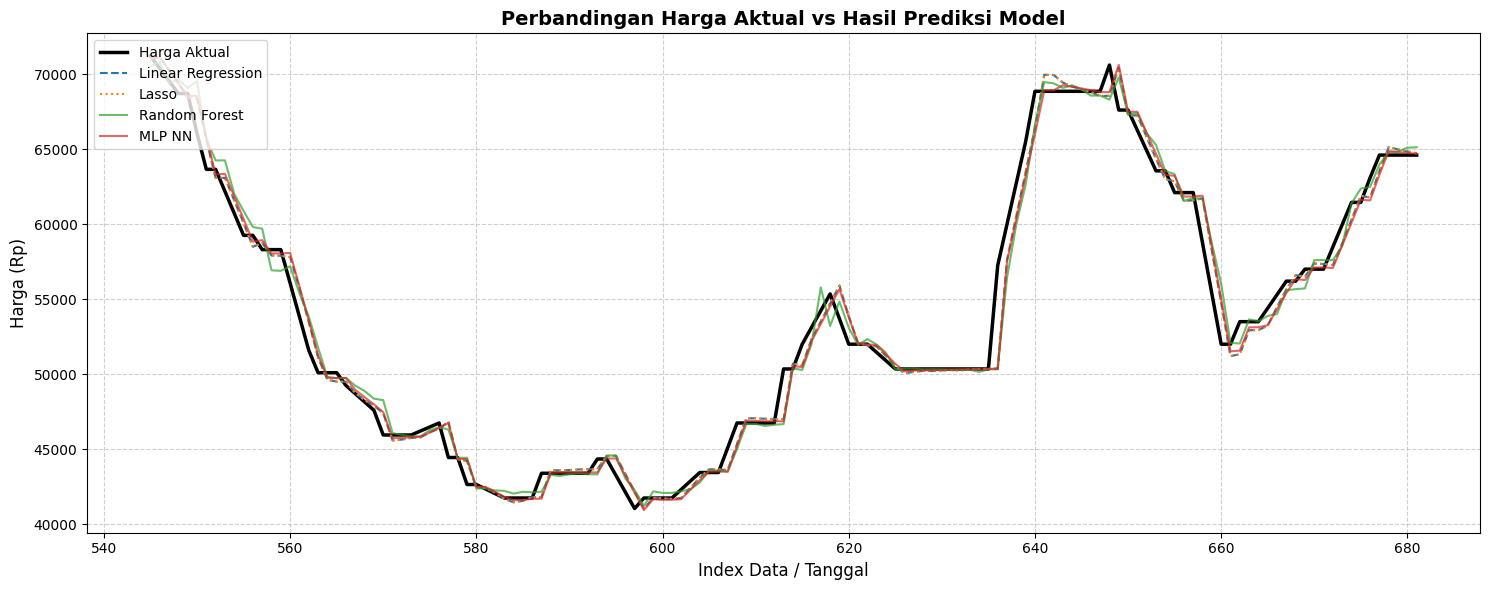

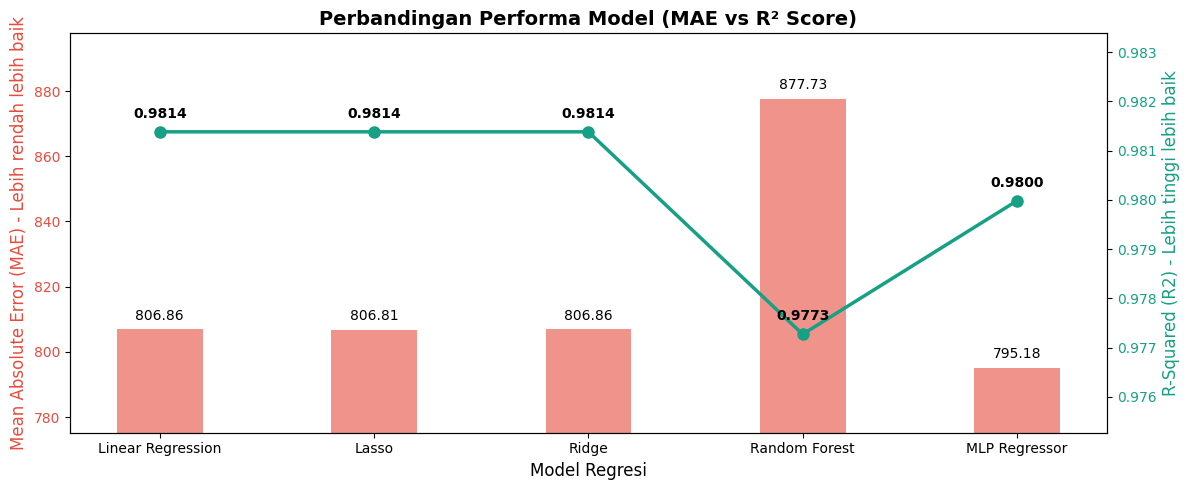

In [54]:
# 1. SIAPKAN DATA UNTUK VISUALISASI
# Membuat dataframe khusus untuk membandingkan nilai aktual vs prediksi
df_visual = pd.DataFrame({
    'Aktual': y_test.values,
    'Linear Regression': y_pred_LR,
    'Lasso': y_pred_LS,
    'Ridge': y_pred_RR,
    'Random Forest': y_pred_RF,
    'MLP Neural Network': y_pred_nn
}, index=y_test.index)

# Data untuk visualisasi metrik performa
models = ['Linear Regression', 'Lasso', 'Ridge', 'Random Forest', 'MLP Regressor']
mae_values = [806.86, 806.81, 806.86, 877.73, 795.18]
r2_values = [0.98138, 0.98138, 0.98138, 0.97727, 0.97998]


# 2. PLOT 1: PERBANDINGAN NILAI AKTUAL VS PREDIKSI (LINE CHART)
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_visual, x=df_visual.index, y='Aktual', label='Harga Aktual', color='black', linewidth=2.5)
sns.lineplot(data=df_visual, x=df_visual.index, y='Linear Regression', label='Linear Regression', linestyle='--')
sns.lineplot(data=df_visual, x=df_visual.index, y='Lasso', label='Lasso', linestyle=':')
sns.lineplot(data=df_visual, x=df_visual.index, y='Random Forest', label='Random Forest', alpha=0.7)
sns.lineplot(data=df_visual, x=df_visual.index, y='MLP Neural Network', label='MLP NN', alpha=0.7)

plt.title('Perbandingan Harga Aktual vs Hasil Prediksi Model', fontsize=14, fontweight='bold')
plt.xlabel('Index Data / Tanggal', fontsize=12)
plt.ylabel('Harga (Rp)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 3. PLOT 2: PERBANDINGAN METRIK EVALUASI (BAR CHART)
fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar plot untuk MAE (Sumbu Y kiri)
color = '#e74c3c'
ax1.set_xlabel('Model Regresi', fontsize=12)
ax1.set_ylabel('Mean Absolute Error (MAE) - Lebih rendah lebih baik', color=color, fontsize=12)
bars = ax1.bar(models, mae_values, color=color, alpha=0.6, width=0.4, label='MAE')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(min(mae_values) - 20, max(mae_values) + 20)

# Menambahkan text label di atas bar MAE
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.2f}', ha='center', va='bottom', color='black')

# Line plot untuk R2 (Sumbu Y kanan / TwinX)
ax2 = ax1.twinx()  
color = '#2ce3a0'
ax2.set_ylabel('R-Squared (R2) - Lebih tinggi lebih baik', color='#16a085', fontsize=12)
line = ax2.plot(models, r2_values, color='#16a085', marker='o', linewidth=2.5, markersize=8, label='R2 Score')
ax2.tick_params(axis='y', labelcolor='#16a085')
ax2.set_ylim(min(r2_values) - 0.002, max(r2_values) + 0.002)

# Menambahkan text label untuk titik R2
for i, txt in enumerate(r2_values):
    ax2.annotate(f'{txt:.4f}', (models[i], r2_values[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title('Perbandingan Performa Model (MAE vs R² Score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Simpan Model

In [56]:
# Simpan semua model yang telah dilatih
import joblib
import os

# bikin folder
os.makedirs('../models', exist_ok=True)


joblib.dump(modelLR, '../models/model_linear.pkl')
joblib.dump(modelLR, '../models/model_ridge.pkl')
joblib.dump(modelLS, '../models/model_lasso.pkl')
joblib.dump(rf_model, '../models/model_rf.pkl')
joblib.dump(nn_model, '../models/model_nn.pkl')


['../models/model_nn.pkl']